In [1]:
import pandas as pd

df = pd.read_csv("report_synthetic_digest.csv")
df = df[(df['rebalance_strategy'] != 'tail-age') | (df['rebalanceDiffRatio'].isna()) | (df['rebalanceDiffRatio'] == 0.25)]

In [5]:
df.columns

Index(['trace_name', 'number_of_requests', 'wsr', 'slab_size', 'slab_cnt',
       'rebalance_strategy', 'allocator', 'tag', 'throughput',
       'rebalanced_slabs', 'miss_ratio', 'n_rebalanced_slabs',
       'monitor_interval', 'n_alloc_failures', 'uuid', 'rebalanceDiffRatio',
       'miss_ratio_reduction_from_disabled',
       'miss_ratio_reduction_from_lru_disabled', 'tuned_improvement'],
      dtype='object')

In [2]:
import pandas as pd

# Filter the DataFrame for 'tail-age' rebalance strategy
filtered_df = df[df['rebalance_strategy'] == 'tail-age']

# Group by trace_name, wsr, and rebalanceDiffRatio, and compute min, max, and mean of n_rebalanced_slabs
result = filtered_df.groupby(['trace_name', 'wsr', 'rebalanceDiffRatio'])['n_rebalanced_slabs'].agg(['min', 'max', 'mean']).reset_index()

# Display the result
print(result)

           trace_name   wsr  rebalanceDiffRatio  min   max        mean
0   synth_dynamic_400  0.01                0.25    0   506  169.333333
1   synth_dynamic_400  0.02                0.25    5   986  332.333333
2   synth_dynamic_400  0.04                0.25   11  1096  373.666667
3   synth_dynamic_400  0.10                0.25   24  1107  398.333333
4   synth_dynamic_400  0.20                0.25   41   893  362.000000
5   synth_dynamic_400  0.40                0.25   67   502  240.666667
6   synth_dynamic_400  0.80                0.25  140   201  171.000000
7    synth_static_202  0.01                0.25    0     0    0.000000
8    synth_static_202  0.02                0.25    0   915  306.333333
9    synth_static_202  0.04                0.25    0  1234  412.666667
10   synth_static_202  0.10                0.25    0  1178  395.666667
11   synth_static_202  0.20                0.25    0  1027  348.000000
12   synth_static_202  0.40                0.25    0   682  235.666667
13   s

In [2]:
import plotly.express as px

def plot_trace_wsr_line_even_x(
    df,
    trace_name,
    y="miss_ratio",
    x="wsr",
    color="rebalance_strategy",
    symbol="allocator",
    title=None
):
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    # Convert wsr to string and set as categorical for even spacing
    plot_df["wsr_str"] = plot_df["wsr"].astype(str)
    wsr_order = sorted(plot_df["wsr"].unique())
    wsr_order_str = [str(w) for w in wsr_order]
    plot_df["wsr_str"] = pd.Categorical(plot_df["wsr_str"], categories=wsr_order_str, ordered=True)

    if title is None:
        title = f"{y} vs {x} for {trace_name}"

    fig = px.line(
        plot_df,
        x="wsr_str",
        y=y,
        color=color,
        symbol=symbol,
        markers=True,
        line_dash=symbol,
        title=title,
        category_orders={
            color: sorted(plot_df[color].unique()),
            symbol: sorted(plot_df[symbol].unique()),
            "wsr_str": wsr_order_str,
        }
    )
    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=f"{color} / {symbol}",
        height=600,
        #yaxis_type="log" if y == "n_rebalanced_slabs" else "linear" 
    )
    fig.show()

In [3]:
import plotly.express as px

def plot_allocator_bar_by_trace_and_wsr(
    df,
    trace_name,
    wsr,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title=None
):
    plot_df = df[(df["trace_name"] == trace_name) & (df["wsr"] == wsr)].copy()
    if plot_df.empty:
        print(f"No data for trace_name={trace_name} and wsr={wsr}")
        return

    # Optional: set consistent order for color
    color_order = [
        "disabled", "free-mem", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned", "lama"
    ]
    plot_df[color] = pd.Categorical(plot_df[color], categories=color_order, ordered=True)

    if title is None:
        title = f"Miss Ratio by Allocator and Rebalance Strategy<br>trace={trace_name}, wsr={wsr}"

    fig = px.bar(
        plot_df,
        x=x,
        y=y,
        color=color,
        barmode="group",
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: color_order}
    )
    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color,
        height=500
    )
    fig.show()

In [4]:
import plotly.express as px
import matplotlib.pyplot as plt

def plot_trace_wsr_line_even_x_three_allocators(
    df,
    trace_name,
    y="miss_ratio",
    x="wsr",
    color="rebalance_strategy",
    title=None
):
    # Filter data for the given trace_name
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    # Convert wsr to string and set as categorical for even spacing
    plot_df["wsr_str"] = plot_df["wsr"].astype(str)
    wsr_order = sorted(plot_df["wsr"].unique())
    wsr_order_str = [str(w) for w in wsr_order]
    plot_df["wsr_str"] = pd.Categorical(plot_df["wsr_str"], categories=wsr_order_str, ordered=True)

    # Filter data for each allocator
    allocators = ["LRU", "LRU2Q", "TINYLFU"]
    allocator_dfs = {alloc: plot_df[plot_df["allocator"] == alloc] for alloc in allocators}

    # Create subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)  # Ensure y-axis is shared
    fig.suptitle(title or f"{y} vs {x} for {trace_name}", fontsize=16)

    for i, alloc in enumerate(allocators):
        ax = axes[i]
        alloc_df = allocator_dfs[alloc]
        if alloc_df.empty:
            ax.set_title(f"{alloc} (No Data)")
            continue

        # Plot each rebalance strategy
        for rebalance_strategy in sorted(alloc_df[color].unique()):
            subset = alloc_df[alloc_df[color] == rebalance_strategy]
            ax.plot(
                subset["wsr_str"],
                subset[y],
                label=rebalance_strategy,
                marker="o",
                linestyle="-",
                markersize=4,
                linewidth=1.5
            )

        ax.set_title(f"{alloc}", fontsize=14)
        ax.set_xlabel(x, fontsize=12)
        if i == 0:  # Only set y-axis label for the first subplot
            ax.set_ylabel(y, fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(title=color, fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit the title
    plt.show()

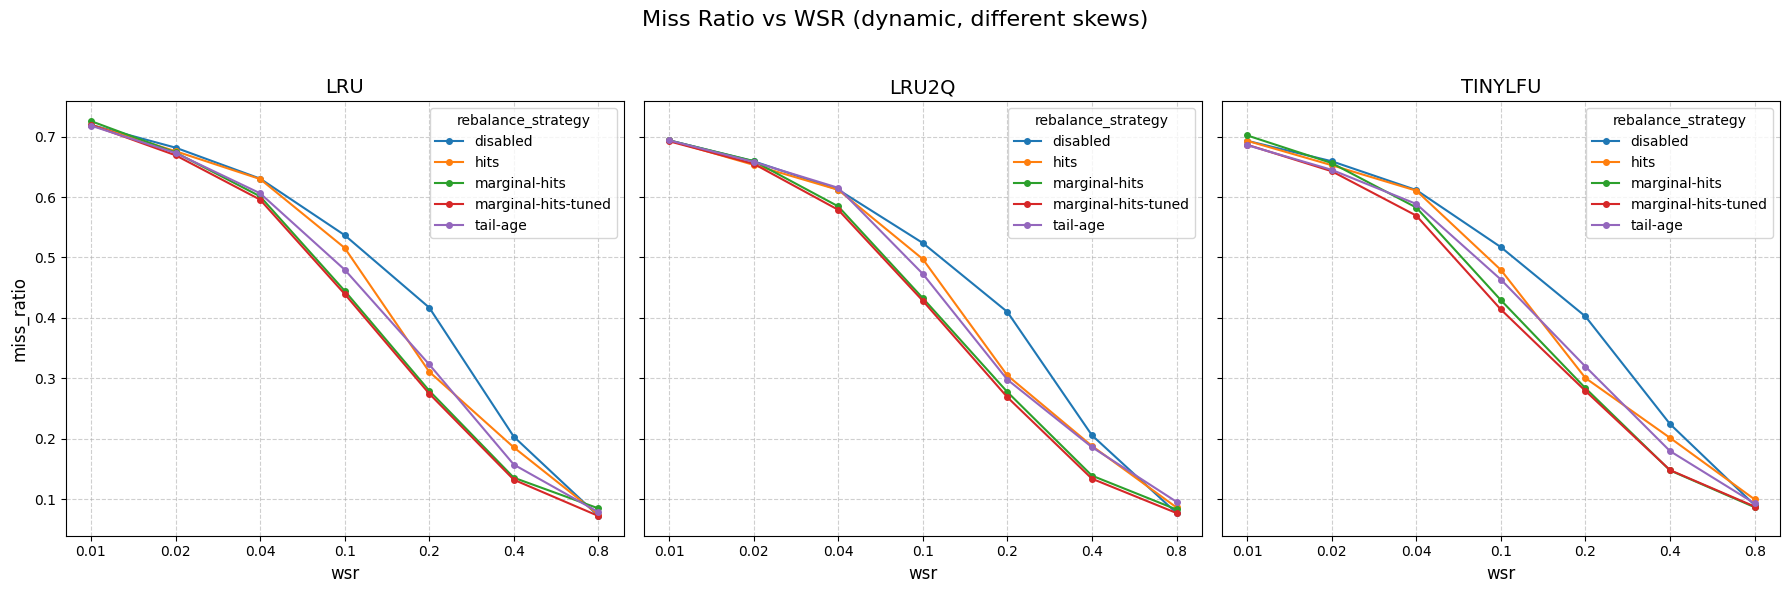

In [5]:
df = df[df['tag'] != 'warm-cold']
plot_trace_wsr_line_even_x_three_allocators(df[df['rebalance_strategy'] != 'free-mem'], "synth_dynamic_400", y="miss_ratio", title="Miss Ratio vs WSR (dynamic, different skews)")

In [15]:
def calculate_improvement_metrics(df, trace_names=None, allocators=None):
    """
    Calculate improvement metrics between marginal-hits and marginal-hits-tuned strategies.
    
    Parameters:
    df: DataFrame containing the data
    trace_names: List of trace names to analyze (if None, analyze all)
    allocators: List of allocators to analyze (if None, analyze all)
    
    Returns:
    DataFrame with improvement metrics
    """
    # Get unique values if not specified
    if trace_names is None:
        trace_names = df['trace_name'].unique()
    if allocators is None:
        allocators = df['allocator'].unique()
    
    results_list = []
    
    for trace_name in trace_names:
        for allocator in allocators:
            # Filter data by trace_name and allocator
            filtered_df = df[(df['trace_name'] == trace_name) & (df['allocator'] == allocator)]
            
            # Get data for both strategies
            marginal_hits = filtered_df[filtered_df['rebalance_strategy'] == 'marginal-hits']
            marginal_hits_tuned = filtered_df[filtered_df['rebalance_strategy'] == 'marginal-hits-tuned']
            
            if marginal_hits.empty or marginal_hits_tuned.empty:
                continue
            
            # Calculate miss_ratio metrics
            miss_ratio_orig = marginal_hits['miss_ratio']
            miss_ratio_tuned = marginal_hits_tuned['miss_ratio']
            
            miss_ratio_avg_reduction = miss_ratio_orig.mean() - miss_ratio_tuned.mean()
            miss_ratio_min_diff = miss_ratio_orig.min() - miss_ratio_tuned.min()
            miss_ratio_max_diff = miss_ratio_orig.max() - miss_ratio_tuned.max()
            
            # Calculate n_rebalanced_slabs metrics
            rebalanced_orig = marginal_hits['n_rebalanced_slabs']
            rebalanced_tuned = marginal_hits_tuned['n_rebalanced_slabs']
            
            rebalanced_avg_reduction_abs = rebalanced_orig.mean() - rebalanced_tuned.mean()
            rebalanced_avg_reduction_rel = (rebalanced_avg_reduction_abs / rebalanced_orig.mean() * 100) if rebalanced_orig.mean() > 0 else 0
            
            result = {
                'trace_name': trace_name,
                'allocator': allocator,
                'miss_ratio_avg_reduction': miss_ratio_avg_reduction,
                'miss_ratio_min_diff': miss_ratio_min_diff,
                'miss_ratio_max_diff': miss_ratio_max_diff,
                'rebalanced_slabs_avg_reduction_abs': rebalanced_avg_reduction_abs,
                'rebalanced_slabs_avg_reduction_rel_pct': rebalanced_avg_reduction_rel,
                # Additional context info
                'marginal_hits_miss_ratio_mean': miss_ratio_orig.mean(),
                'marginal_hits_tuned_miss_ratio_mean': miss_ratio_tuned.mean(),
                'marginal_hits_rebalanced_mean': rebalanced_orig.mean(),
                'marginal_hits_tuned_rebalanced_mean': rebalanced_tuned.mean()
            }
            results_list.append(result)
    
    return pd.DataFrame(results_list)

# Usage
improvement_df = calculate_improvement_metrics(df)
display(improvement_df)

# For specific traces
specific_traces = ["synth_static_202", "synth_dynamic_400"]
specific_allocators = ["LRU", "LRU2Q", "TINYLFU"]
improvement_df = calculate_improvement_metrics(df, trace_names=specific_traces, allocators=specific_allocators)
display(improvement_df[improvement_df['trace_name'] != 'synth_static_204'])



,trace_name,allocator,miss_ratio_avg_reduction,miss_ratio_min_diff,miss_ratio_max_diff,rebalanced_slabs_avg_reduction_abs,rebalanced_slabs_avg_reduction_rel_pct,marginal_hits_miss_ratio_mean,marginal_hits_tuned_miss_ratio_mean,marginal_hits_rebalanced_mean,marginal_hits_tuned_rebalanced_mean
0,synth_dynamic_400,LRU,0.006010,0.012549,0.006084,1215.428571,87.530864,0.420725,0.414715,1388.571429,173.142857
1,synth_dynamic_400,LRU2Q,0.005096,0.005856,0.001475,690.714286,80.637091,0.410003,0.404907,856.571429,165.857143
2,synth_dynamic_400,TINYLFU,0.008668,-0.001128,0.015436,1107.285714,79.611750,0.412586,0.403919,1390.857143,283.571429
3,synth_static_202,LRU,0.005213,0.006652,0.000000,1228.000000,92.859458,0.516494,0.511281,1322.428571,94.428571
4,synth_static_202,LRU2Q,0.009185,0.006346,0.000000,1175.428571,94.045034,0.504013,0.494828,1249.857143,74.428571
5,synth_static_202,TINYLFU,0.014089,0.008626,0.000000,1227.428571,92.736104,0.496257,0.482168,1323.571429,96.142857
6,synth_static_204,LRU,0.011274,0.005358,0.000000,1204.000000,93.779904,0.258362,0.247088,1283.857143,79.857143
7,synth_static_204,LRU2Q,0.014505,0.005238,0.000000,1123.714286,91.678322,0.246079,0.231573,1225.714286,102.000000
8,synth_static_204,TINYLFU,0.016716,0.005207,0.000000,1175.142857,91.572971,0.241930,0.225214,1283.285714,108.142857


,trace_name,allocator,miss_ratio_avg_reduction,miss_ratio_min_diff,miss_ratio_max_diff,rebalanced_slabs_avg_reduction_abs,rebalanced_slabs_avg_reduction_rel_pct,marginal_hits_miss_ratio_mean,marginal_hits_tuned_miss_ratio_mean,marginal_hits_rebalanced_mean,marginal_hits_tuned_rebalanced_mean
0,synth_static_202,LRU,0.005213,0.006652,0.000000,1228.000000,92.859458,0.516494,0.511281,1322.428571,94.428571
1,synth_static_202,LRU2Q,0.009185,0.006346,0.000000,1175.428571,94.045034,0.504013,0.494828,1249.857143,74.428571
2,synth_static_202,TINYLFU,0.014089,0.008626,0.000000,1227.428571,92.736104,0.496257,0.482168,1323.571429,96.142857
3,synth_dynamic_400,LRU,0.006010,0.012549,0.006084,1215.428571,87.530864,0.420725,0.414715,1388.571429,173.142857
4,synth_dynamic_400,LRU2Q,0.005096,0.005856,0.001475,690.714286,80.637091,0.410003,0.404907,856.571429,165.857143
5,synth_dynamic_400,TINYLFU,0.008668,-0.001128,0.015436,1107.285714,79.611750,0.412586,0.403919,1390.857143,283.571429


In [7]:
df.to_csv("/nfs/hongshu/thesis-playground/thesis-plotting/scripts/tune_details/miss_ratios_synthetic.csv", index=False)

In [13]:
plot_trace_wsr_line_even_x(df, "synth_dynamic_400", y="miss_ratio", title="Miss Ratio vs WSR (static different skews)")


In [15]:
df['tag'].unique()

array([nan, 'warm-cold', 'cold'], dtype=object)